#**CNN: Covid-19**

Был выбран датасет с фотографиями флюрографий разделенных на 2 группы: здоровые и пневмония
---
Стоит задача в сфере компьютерного зрения и бинарной классификации через сверточную нейронную сеть
---
За основу возьмем базовую модель VGG16
---
Датасет сразу разделен на тестовую и тренировочную выборку
---
Ссылка на датасет: [Перейти](https://www.kaggle.com/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/data)
---

## VGG16 Base model setup

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

In [4]:
base_dir = '/content/drive/MyDrive/Colab Notebooks/Third semester/Exams/CNN/xray_dataset_covid19'

In [5]:
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 148 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [8]:
conv_base = VGG16(weights='imagenet',
                  include_top = False,
                  input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
conv_base.trainable = False

In [10]:
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation = 'relu'))
# Выключаем 50% случаных нейронов, чтобы избежать переобучения
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation = 'sigmoid'))

In [11]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Callbacks

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [14]:
checkpoint = ModelCheckpoint(
    'best_covid_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1,
    mode='max',
    restore_best_weights=True
)

In [16]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=0.00001
)

In [17]:
callbacks_list = [checkpoint, early_stop, reduce_lr]

## Обучение модели

In [18]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    callbacks=callbacks_list
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5882 - loss: 0.6302
Epoch 1: val_accuracy improved from -inf to 0.80000, saving model to best_covid_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 83s 15s/step - accuracy: 0.6084 - loss: 0.6109 - val_accuracy: 0.8000 - val_loss: 0.3485 - learning_rate: 1.0000e-04
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.8941 - loss: 0.2414
Epoch 2: val_accuracy improved from 0.80000 to 0.92500, saving model to best_covid_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8993 - loss: 0.2369 - val_accuracy: 0.9250 - val_loss: 0.1212 - learning_rate: 1.0000e-04
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9474 - loss: 0.1275
Epoch 3: val_accuracy improved from 0.92500 to 0.97500, saving model to best_covid_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9483 - loss: 0.1277 - val_accuracy: 0.9750 - val_loss: 0.1177 - learning_rate: 1.0000e-04
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step 

In [19]:
sns.set_style("whitegrid")

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

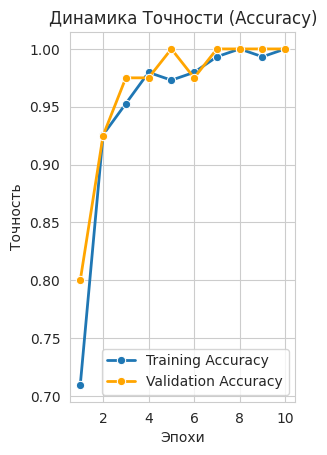

In [21]:
plt.subplot(1, 2, 1)
sns.lineplot(x=epochs, y=acc, label='Training Accuracy', linewidth=2, marker='o')
sns.lineplot(x=epochs, y=val_acc, label='Validation Accuracy', linewidth=2, marker='o', color='orange')
plt.title('Динамика Точности (Accuracy)')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

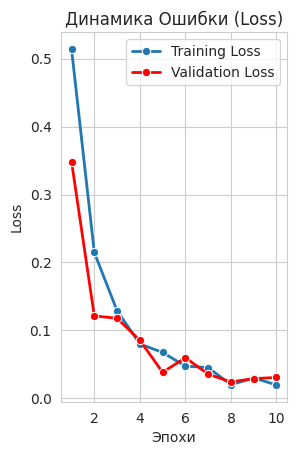

In [22]:
plt.subplot(1, 2, 2)
sns.lineplot(x=epochs, y=loss, label='Training Loss', linewidth=2, marker='o')
sns.lineplot(x=epochs, y=val_loss, label='Validation Loss', linewidth=2, marker='o', color='red')
plt.title('Динамика Ошибки (Loss)')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [23]:
print("\n--- Генерация Матрицы Ошибок ---")


--- Генерация Матрицы Ошибок ---


In [24]:
eval_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 40 images belonging to 2 classes.


In [25]:
predictions = model.predict(eval_generator)
y_pred = (predictions > 0.5).astype(int).ravel()
y_true = eval_generator.classes

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 661ms/step


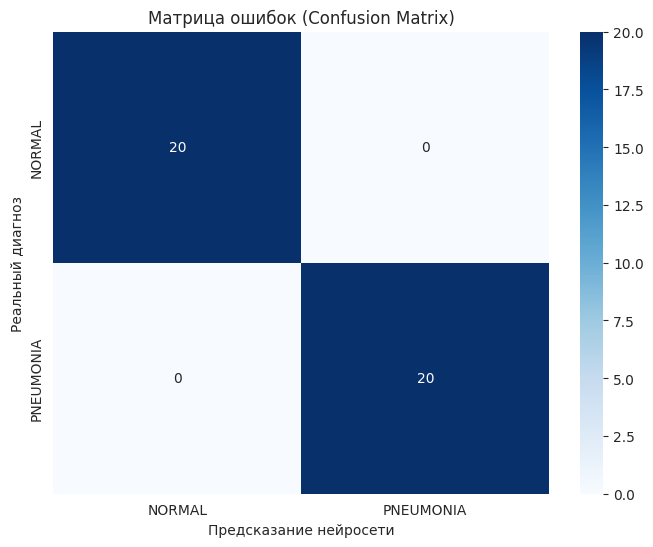

In [26]:
cm = confusion_matrix(y_true, y_pred)
class_names = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Предсказание нейросети')
plt.ylabel('Реальный диагноз')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

In [27]:
print("\n--- Подробный отчет ---")
print(classification_report(y_true, y_pred, target_names=class_names))


--- Подробный отчет ---
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        20
   PNEUMONIA       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

